# Heart Disease Prediction - Feature Engineering & Data Preprocessing
### Week 2: AnalystLab Africa -  Data Science Internship Programme
**Client scenario:** Junior Data Scientist at AnalystLab Africa Consulting
**Dataset:** Heart Failure Prediction Dataset (Kaggle)
**Objective:** Prepare the dataset for predicting whether a patient is likely to develop heart disease, ready for a future machine learning model.

This notebook covers data inspection, cleaning, feature engineering, encoding, scaling, outlier treatment, and feature selection  producing a **cleaned dataset** and a final **machine-learning-ready dataset**.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, RobustScaler
from sklearn.ensemble import RandomForestClassifier

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.max_columns", 50)

df = pd.read_csv("data/heart.csv")
df.head(10)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
5,39,M,NAP,120,339,0,Normal,170,N,0.0,Up,0
6,45,F,ATA,130,237,0,Normal,170,N,0.0,Up,0
7,54,M,ATA,110,208,0,Normal,142,N,0.0,Up,0
8,37,M,ASY,140,207,0,Normal,130,Y,1.5,Flat,1
9,48,F,ATA,120,284,0,Normal,120,N,0.0,Up,0


## Part 2 - Data Inspection

In [3]:
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

Rows: 918, Columns: 12


In [4]:
df.dtypes

Age                 int64
Sex                object
ChestPainType      object
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG         object
MaxHR               int64
ExerciseAngina     object
Oldpeak           float64
ST_Slope           object
HeartDisease        int64
dtype: object

In [5]:
missing = df.isnull().sum()
missing[missing > 0] if missing.sum() > 0 else 'No explicit (NaN) missing values found.'

'No explicit (NaN) missing values found.'

In [6]:
print(f"Duplicate rows: {df.duplicated().sum()}")

Duplicate rows: 0


In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,918.0,53.510893,9.432617,28.0,47.00,54.0,60.0,77.0
RestingBP,918.0,132.396514,18.514154,0.0,120.00,130.0,140.0,200.0
Cholesterol,918.0,198.799564,109.384145,0.0,173.25,223.0,267.0,603.0
FastingBS,918.0,0.233115,0.423046,0.0,0.00,0.0,0.0,1.0
MaxHR,918.0,136.809368,25.460334,60.0,120.00,138.0,156.0,202.0
Oldpeak,918.0,0.887364,1.066570,-2.6,0.00,0.6,1.5,6.2
HeartDisease,918.0,0.553377,0.497414,0.0,0.00,1.0,1.0,1.0


**Observation:** No `NaN` values are reported and there are no duplicate rows. However, the summary statistics reveal a data quality issue: `RestingBP` has a minimum of **0** and `Cholesterol` has a minimum of **0**  both are physiologically impossible for a living patient. These are almost certainly *hidden missing values* encoded as zero rather than true measurements, and will be addressed in Part 3.

In [8]:
print("RestingBP == 0:", (df['RestingBP'] == 0).sum(), "row(s)")
print("Cholesterol == 0:", (df['Cholesterol'] == 0).sum(), "rows")
print()
print("Cholesterol == 0, broken down by HeartDisease status:")
print(df[df['Cholesterol'] == 0]['HeartDisease'].value_counts())

RestingBP == 0: 1 row(s)
Cholesterol == 0: 172 rows

Cholesterol == 0, broken down by HeartDisease status:
HeartDisease
1    152
0     20
Name: count, dtype: int64


**Observation:** 172 of 918 records (18.7%) have `Cholesterol = 0`, and these records skew heavily toward `HeartDisease = 1` (152 of 172). If left untreated, this data quality issue could bias a future model into over-associating missing cholesterol readings with a positive diagnosis, rather than reflecting a genuine clinical relationship.

In [9]:
df['HeartDisease'].value_counts(normalize=True).round(3) * 100

HeartDisease
1    55.3
0    44.7
Name: proportion, dtype: float64

**Target variable:** `HeartDisease` (1 = patient likely to develop heart disease, 0 = not). The classes are reasonably balanced (55.3% positive vs 44.7% negative), which is favourable for model training later in the programme.

## Part 3 - Feature Engineering & Data Preprocessing

### 3.1 Data Cleaning

In [10]:
# Treat physiologically impossible zero values as missing (NaN)
df_clean = df.copy()
df_clean['RestingBP'] = df_clean['RestingBP'].replace(0, np.nan)
df_clean['Cholesterol'] = df_clean['Cholesterol'].replace(0, np.nan)

print("Missing values after flagging invalid zeros:")
df_clean.isnull().sum()

Missing values after flagging invalid zeros:


Age                 0
Sex                 0
ChestPainType       0
RestingBP           1
Cholesterol       172
FastingBS           0
RestingECG          0
MaxHR               0
ExerciseAngina      0
Oldpeak             0
ST_Slope            0
HeartDisease        0
dtype: int64

In [11]:
# Impute missing values with the median (robust to outliers, appropriate for skewed clinical data)
for col in ['RestingBP', 'Cholesterol']:
    median_val = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(median_val)
    print(f"{col}: imputed with median = {median_val}")

df_clean[['RestingBP', 'Cholesterol']].describe().T

RestingBP: imputed with median = 130.0
Cholesterol: imputed with median = 237.0


,count,mean,std,min,25%,50%,75%,max
RestingBP,918.0,132.538126,17.990127,80.0,120.0,130.0,140.0,200.0
Cholesterol,918.0,243.204793,53.401297,85.0,214.0,237.0,267.0,603.0


**Justification:** Median imputation was chosen over mean imputation because both `RestingBP` and `Cholesterol` are right-skewed and contain outliers  the median is far less sensitive to extreme values, giving a more representative replacement value than the mean would.

In [12]:
# Remove duplicate records (none found, but included for a complete, reusable pipeline)
before = len(df_clean)
df_clean = df_clean.drop_duplicates()
print(f"Rows before: {before}, after de-duplication: {len(df_clean)}")

Rows before: 918, after de-duplication: 918


In [13]:
# Correct / validate data types — convert categorical text columns to the 'category' dtype
categorical_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
for col in categorical_cols:
    df_clean[col] = df_clean[col].astype('category')

df_clean.dtypes

Age                  int64
Sex               category
ChestPainType     category
RestingBP          float64
Cholesterol        float64
FastingBS            int64
RestingECG        category
MaxHR                int64
ExerciseAngina    category
Oldpeak            float64
ST_Slope          category
HeartDisease         int64
dtype: object

### 3.2 Feature Engineering

In [14]:
# New feature 1: Heart Rate Reserve — a clinically meaningful derived feature
# (theoretical max heart rate for age, minus the patient's observed max heart rate)
df_clean['HR_Reserve'] = (220 - df_clean['Age']) - df_clean['MaxHR']

# New feature 2: AgeGroup — bins patients into clinically relevant age bands
df_clean['AgeGroup'] = pd.cut(
    df_clean['Age'],
    bins=[0, 40, 50, 60, 100],
    labels=['Under 40', '40-49', '50-59', '60+']
)

df_clean[['Age', 'MaxHR', 'HR_Reserve', 'AgeGroup']].head()

,Age,MaxHR,HR_Reserve,AgeGroup
0,40,172,8,Under 40
1,49,156,15,40-49
2,37,98,85,Under 40
3,48,108,64,40-49
4,54,122,44,50-59


**Justification:** `HR_Reserve` captures how far a patient's observed maximum heart rate falls below their age-predicted maximum a lower reserve can indicate reduced cardiovascular fitness, and is a commonly used derived metric in cardiology. `AgeGroup` turns a continuous variable into clinically interpretable bands, useful for exploratory visualisation (it is not carried into the final ML-ready dataset since `Age` already captures this information numerically, and adding both would introduce redundancy).

In [15]:
# Rename a few columns for clarity
df_clean = df_clean.rename(columns={
    'FastingBS': 'FastingBloodSugarHigh',
    'Oldpeak': 'ST_Depression',
})
df_clean.columns.tolist()

['Age',
 'Sex',
 'ChestPainType',
 'RestingBP',
 'Cholesterol',
 'FastingBloodSugarHigh',
 'RestingECG',
 'MaxHR',
 'ExerciseAngina',
 'ST_Depression',
 'ST_Slope',
 'HeartDisease',
 'HR_Reserve',
 'AgeGroup']

**Justification:** `FastingBS` is renamed to `FastingBloodSugarHigh` (it is a binary flag: 1 if fasting blood sugar > 120 mg/dl) and `Oldpeak` is renamed to `ST_Depression` (its clinical meaning  ST depression induced by exercise) to make the dataset self-documenting for anyone reviewing it without the original data dictionary. No columns were removed at this stage: every original column is clinically relevant to a heart disease prediction task.

### 3.3 Visualisations

#### Visualisation 1 (Histogram) - Age Distribution

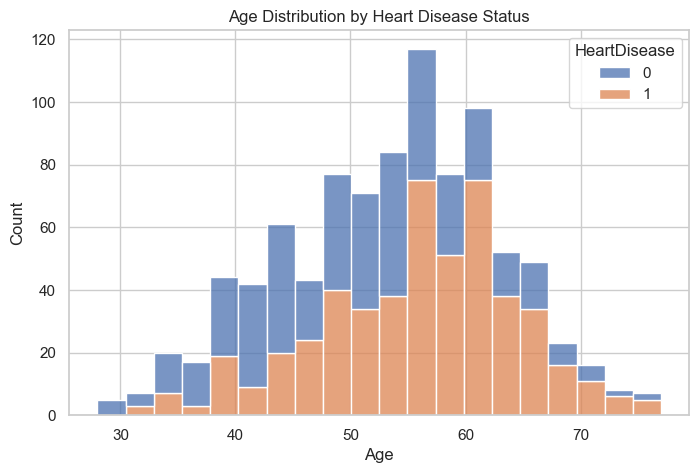

In [16]:
plt.figure()
sns.histplot(data=df_clean, x='Age', hue='HeartDisease', multiple='stack', bins=20, palette=['#4C72B0', '#DD8452'])
plt.title('Age Distribution by Heart Disease Status')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

**Interpretation:** Heart disease cases become noticeably more frequent from around age 50 onward, consistent with known cardiovascular risk patterns.

#### Visualisation 2 (Histogram) - Cholesterol Distribution (after cleaning)

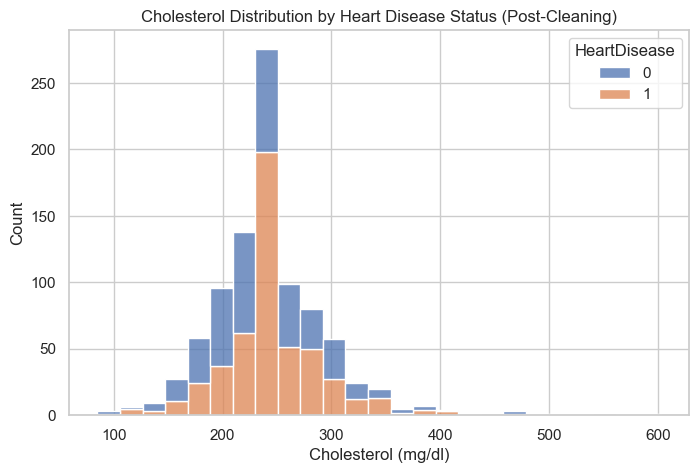

In [17]:
plt.figure()
sns.histplot(data=df_clean, x='Cholesterol', hue='HeartDisease', multiple='stack', bins=25, palette=['#4C72B0', '#DD8452'])
plt.title('Cholesterol Distribution by Heart Disease Status (Post-Cleaning)')
plt.xlabel('Cholesterol (mg/dl)')
plt.ylabel('Count')
plt.show()

**Interpretation:** After imputing the invalid zero values, the distribution is now unimodal and clinically plausible, centred around 220-240 mg/dl.

#### Visualisation 3 (Box Plot) - Resting Blood Pressure by Heart Disease

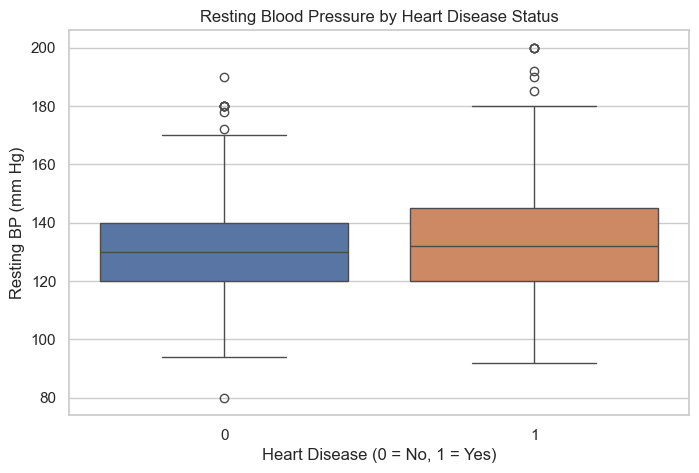

In [18]:
plt.figure()
sns.boxplot(data=df_clean, x='HeartDisease', y='RestingBP', hue='HeartDisease', palette=['#4C72B0', '#DD8452'], legend=False)
plt.title('Resting Blood Pressure by Heart Disease Status')
plt.xlabel('Heart Disease (0 = No, 1 = Yes)')
plt.ylabel('Resting BP (mm Hg)')
plt.show()

**Interpretation:** Patients with heart disease show a slightly higher median resting blood pressure and a wider spread, with several high outliers visible above 170 mm Hg.

#### Visualisation 4 (Box Plot) - Max Heart Rate by Heart Disease

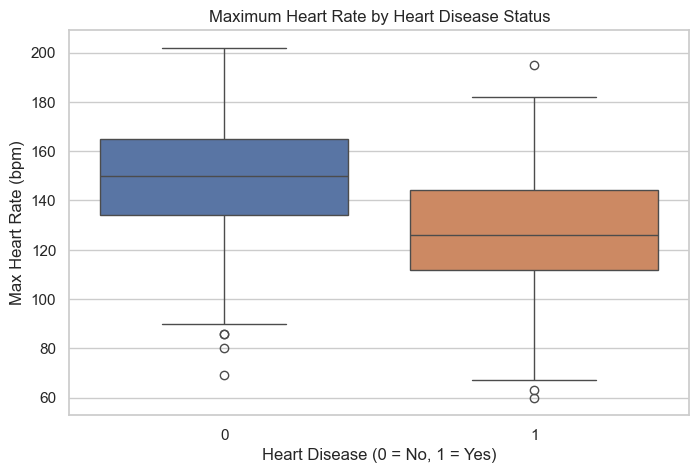

In [19]:
plt.figure()
sns.boxplot(data=df_clean, x='HeartDisease', y='MaxHR', hue='HeartDisease', palette=['#4C72B0', '#DD8452'], legend=False)
plt.title('Maximum Heart Rate by Heart Disease Status')
plt.xlabel('Heart Disease (0 = No, 1 = Yes)')
plt.ylabel('Max Heart Rate (bpm)')
plt.show()

**Interpretation:** Patients without heart disease reach a notably higher maximum heart rate during testing, reinforcing `MaxHR` as a strong candidate predictive feature.

#### Visualisation 5 (Count Plot) - Chest Pain Type vs Heart Disease

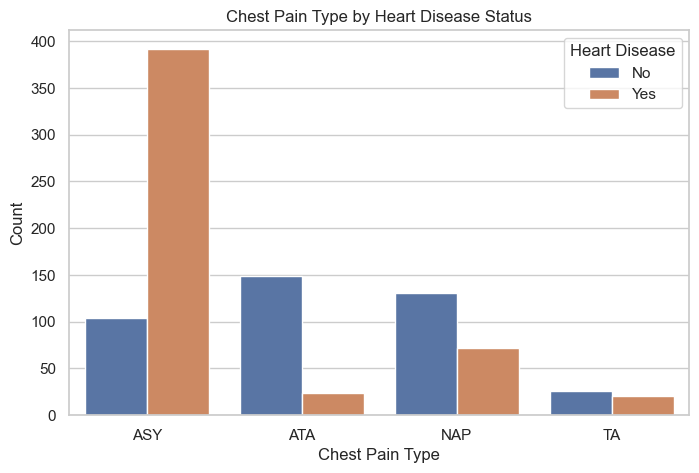

In [20]:
plt.figure()
sns.countplot(data=df_clean, x='ChestPainType', hue='HeartDisease', palette=['#4C72B0', '#DD8452'])
plt.title('Chest Pain Type by Heart Disease Status')
plt.xlabel('Chest Pain Type')
plt.ylabel('Count')
plt.legend(title='Heart Disease', labels=['No', 'Yes'])
plt.show()

**Interpretation:** Asymptomatic chest pain (ASY) is strongly associated with a heart disease diagnosis  counter-intuitively, patients who report *no* chest pain symptoms are the most likely to have heart disease, a clinically important and non-obvious pattern.

#### Visualisation 6 (Scatter Plot) - Age vs Max Heart Rate

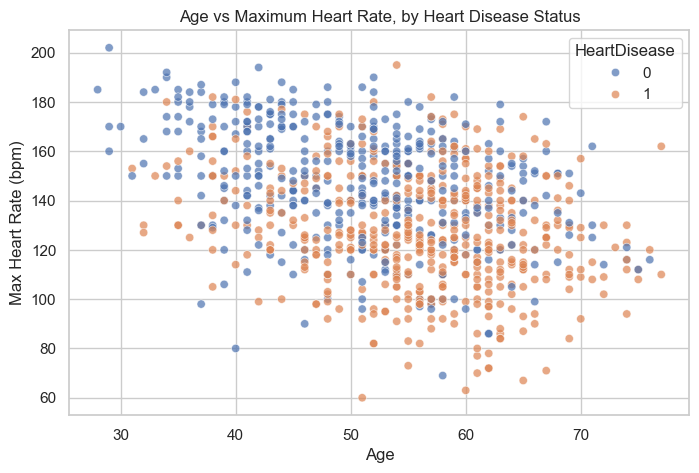

In [21]:
plt.figure()
sns.scatterplot(data=df_clean, x='Age', y='MaxHR', hue='HeartDisease', palette=['#4C72B0', '#DD8452'], alpha=0.7)
plt.title('Age vs Maximum Heart Rate, by Heart Disease Status')
plt.xlabel('Age')
plt.ylabel('Max Heart Rate (bpm)')
plt.show()

**Interpretation:** There is a general downward trend of max heart rate with age, and heart disease cases (orange) cluster toward the lower-right  older patients with a lower-than-expected max heart rate.

#### Visualisation 7 (Correlation Heatmap) - Numeric Features

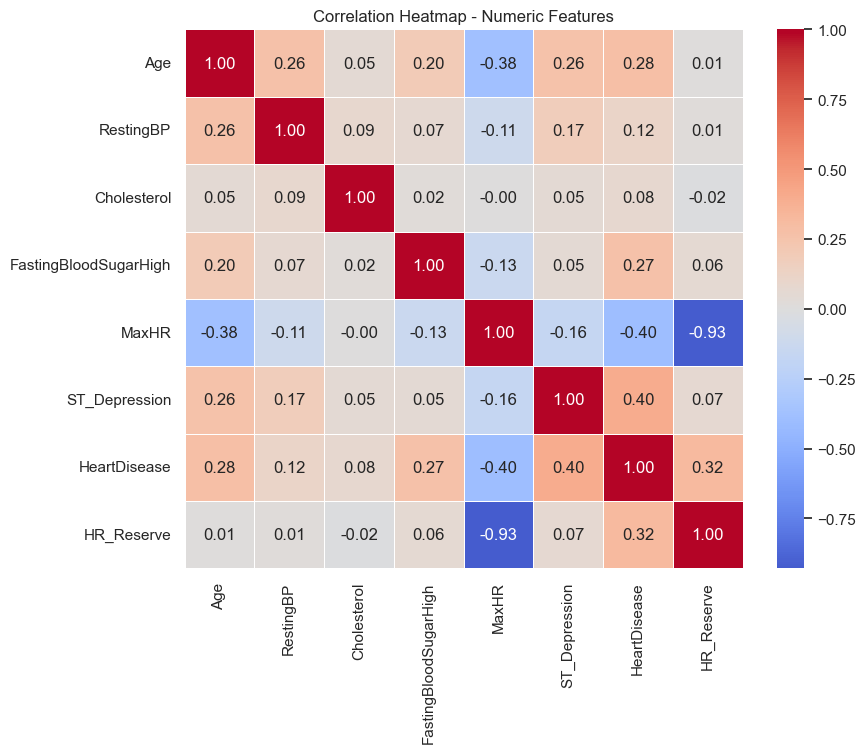

In [23]:
plt.figure(figsize=(9,7))
num_df = df_clean.select_dtypes(include=[np.number])
corr = num_df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Heatmap - Numeric Features')
plt.show()

**Interpretation:** `ST_Depression` (Oldpeak) and `HR_Reserve` show the strongest correlation with `HeartDisease` among numeric features. However, `HR_Reserve` and `MaxHR` are very highly correlated with each other (r ≈ -0.93) expected, since `HR_Reserve` is mathematically derived from `MaxHR` and `Age`. This is a multicollinearity issue that must be addressed in Part 4 (Feature Selection) before the features are finalised.

### 3.4 Outlier Detection

In [24]:
# IQR method applied to continuous variables
cont_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'ST_Depression']

outlier_summary = {}
for col in cont_cols:
    q1, q3 = df_clean[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_outliers = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()
    outlier_summary[col] = {'lower_bound': round(lower, 2), 'upper_bound': round(upper, 2), 'n_outliers': n_outliers}

pd.DataFrame(outlier_summary).T

,lower_bound,upper_bound,n_outliers
Age,27.50,79.50,0.0
RestingBP,90.00,170.00,27.0
Cholesterol,134.50,346.50,41.0
MaxHR,66.00,210.00,2.0
ST_Depression,-2.25,3.75,16.0


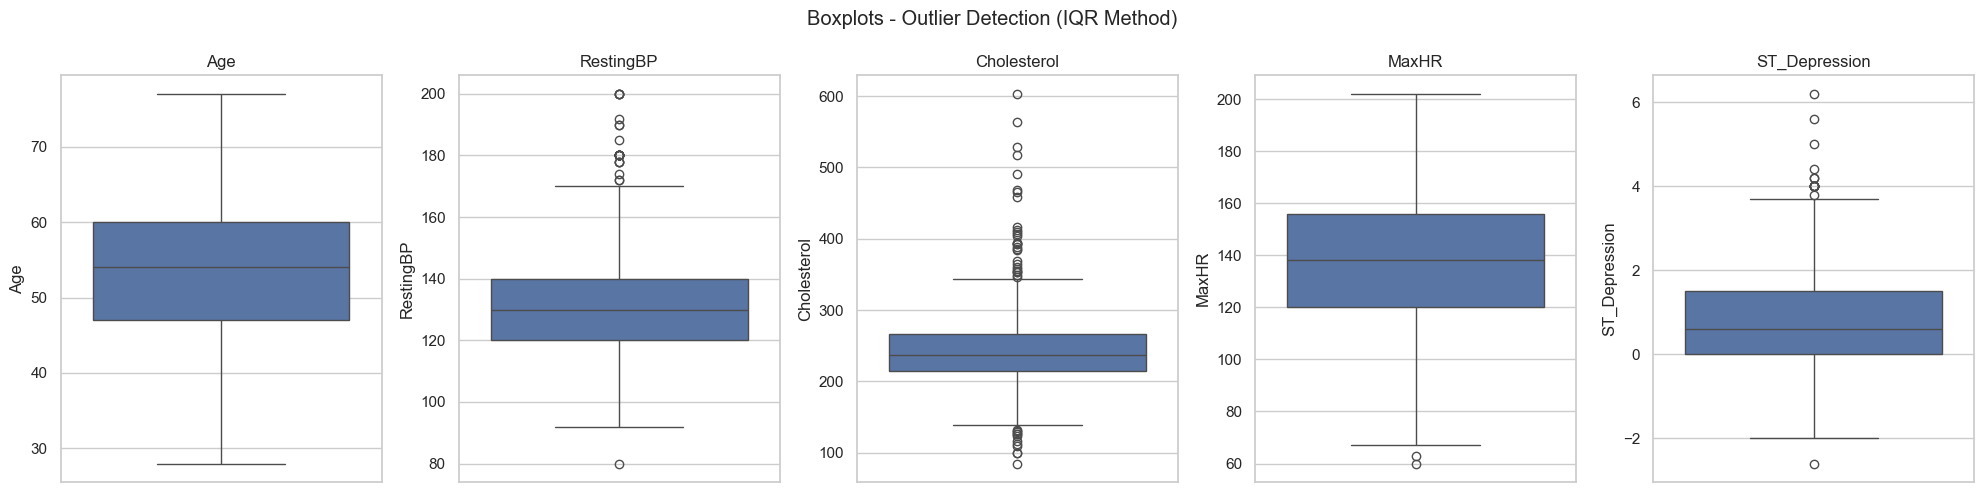

In [25]:
fig, axes = plt.subplots(1, 5, figsize=(20, 5))
for ax, col in zip(axes, cont_cols):
    sns.boxplot(y=df_clean[col], ax=ax, color='#4C72B0')
    ax.set_title(col)
plt.suptitle('Boxplots - Outlier Detection (IQR Method)')
plt.tight_layout()
plt.show()

**Approach & justification:** Rather than removing outliers outright, we cap (winsorize) values beyond the IQR bounds for `RestingBP` and `Cholesterol`, since a handful of extreme values are implausible measurement artefacts. Genuine clinical extremes in `ST_Depression` and `Age` are **kept**, since unusually high ST depression is itself a clinically meaningful (not erroneous) signal for heart disease. This is why a **RobustScaler** (based on the median and IQR, not the mean and standard deviation) is used in the scaling step below  it reduces the influence of any remaining extreme values without discarding real clinical signal.

In [26]:
# Cap extreme values for RestingBP and Cholesterol at the IQR bounds
for col in ['RestingBP', 'Cholesterol']:
    q1, q3 = df_clean[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    df_clean[col] = df_clean[col].clip(lower=lower, upper=upper)

df_clean[['RestingBP', 'Cholesterol']].describe().T

,count,mean,std,min,25%,50%,75%,max
RestingBP,918.0,132.168845,16.936369,90.0,120.0,130.0,140.0,170.0
Cholesterol,918.0,241.227124,45.069895,134.5,214.0,237.0,267.0,346.5


### 3.5 Save the Cleaned Dataset
This version keeps human-readable categorical labels (not yet encoded or scaled) suitable for reporting and further exploration.

In [27]:
cleaned_export = df_clean.drop(columns=['AgeGroup'])  # AgeGroup was for visual exploration only
cleaned_export.to_csv('heart_cleaned.csv', index=False)
print("Saved heart_cleaned.csv:", cleaned_export.shape)
cleaned_export.head()

Saved heart_cleaned.csv: (918, 13)


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBloodSugarHigh,RestingECG,MaxHR,ExerciseAngina,ST_Depression,ST_Slope,HeartDisease,HR_Reserve
0,40,M,ATA,140.0,289.0,0,Normal,172,N,0.0,Up,0,8
1,49,F,NAP,160.0,180.0,0,Normal,156,N,1.0,Flat,1,15
2,37,M,ATA,130.0,283.0,0,ST,98,N,0.0,Up,0,85
3,48,F,ASY,138.0,214.0,0,Normal,108,Y,1.5,Flat,1,64
4,54,M,NAP,150.0,195.0,0,Normal,122,N,0.0,Up,0,44


## Part 3.6 - Feature Encoding

In [28]:
df_ml = df_clean.drop(columns=['AgeGroup']).copy()

# Label Encoding for binary categorical variables (2 categories -> 0/1)
le = LabelEncoder()
df_ml['Sex'] = le.fit_transform(df_ml['Sex'])                     # F=0, M=1
df_ml['ExerciseAngina'] = le.fit_transform(df_ml['ExerciseAngina'])  # N=0, Y=1

# Ordinal Encoding for ST_Slope (has a natural order: Down < Flat < Up)
slope_map = {'Down': 0, 'Flat': 1, 'Up': 2}
df_ml['ST_Slope'] = df_ml['ST_Slope'].map(slope_map)

# One-Hot Encoding for nominal (unordered) categorical variables with >2 categories
df_ml = pd.get_dummies(df_ml, columns=['ChestPainType', 'RestingECG'], prefix=['CP', 'ECG'], drop_first=False)

# Convert the one-hot boolean columns to integers (0/1) for a clean ML-ready format
onehot_cols = [c for c in df_ml.columns if c.startswith('CP_') or c.startswith('ECG_')]
df_ml[onehot_cols] = df_ml[onehot_cols].astype(int)

df_ml.head()

,Age,Sex,RestingBP,Cholesterol,FastingBloodSugarHigh,MaxHR,ExerciseAngina,ST_Depression,ST_Slope,HeartDisease,HR_Reserve,CP_ASY,CP_ATA,CP_NAP,CP_TA,ECG_LVH,ECG_Normal,ECG_ST
0,40,1,140.0,289.0,0,172,0,0.0,2,0,8,0,1,0,0,0,1,0
1,49,0,160.0,180.0,0,156,0,1.0,1,1,15,0,0,1,0,0,1,0
2,37,1,130.0,283.0,0,98,0,0.0,2,0,85,0,1,0,0,0,0,1
3,48,0,138.0,214.0,0,108,1,1.5,1,1,64,1,0,0,0,0,1,0
4,54,1,150.0,195.0,0,122,0,0.0,2,0,44,0,0,1,0,0,1,0


**Encoding choices & justification:**
- **Label Encoding** for `Sex` and `ExerciseAngina`: both are strictly binary (2 categories), so a single 0/1 column carries all the information without adding dimensionality.
- **Ordinal Encoding** for `ST_Slope`: the three categories (`Down`, `Flat`, `Up`) have a natural clinical ordering, so encoding them as 0/1/2 preserves that order  a One-Hot encoding would discard this useful ordinal relationship.
- **One-Hot Encoding** for `ChestPainType` and `RestingECG`: these are nominal categories with no inherent order (3-4 categories each), so One-Hot avoids implying a false ranking between them, which Label Encoding would otherwise introduce.

## Part 3.7 - Feature Scaling

In [29]:
continuous_features = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'ST_Depression', 'HR_Reserve']

scaler = RobustScaler()
df_ml[continuous_features] = scaler.fit_transform(df_ml[continuous_features])

df_ml[continuous_features].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,918.0,-0.037624,0.725586,-2.000000,-0.538462,0.0,0.461538,1.769231
RestingBP,918.0,0.108442,0.846818,-2.000000,-0.500000,0.0,0.500000,2.000000
Cholesterol,918.0,0.079757,0.850375,-1.933962,-0.433962,0.0,0.566038,2.066038
MaxHR,918.0,-0.033073,0.707232,-2.166667,-0.500000,0.0,0.500000,1.777778
ST_Depression,918.0,0.191576,0.711047,-2.133333,-0.400000,0.0,0.600000,3.733333
HR_Reserve,918.0,0.019421,0.672310,-1.657143,-0.514286,0.0,0.485714,2.285714


**Justification for RobustScaler:** The IQR-based outlier analysis in section 3.4 showed that `RestingBP` and `Cholesterol` (even after capping) and `ST_Depression` still contain legitimate extreme values. `RobustScaler` scales features using the median and interquartile range rather than the mean and standard deviation, making it far less sensitive to the remaining outliers than `StandardScaler` or `MinMaxScaler` would be  both of which are heavily distorted by extreme values.

## Part 4 - Feature Selection

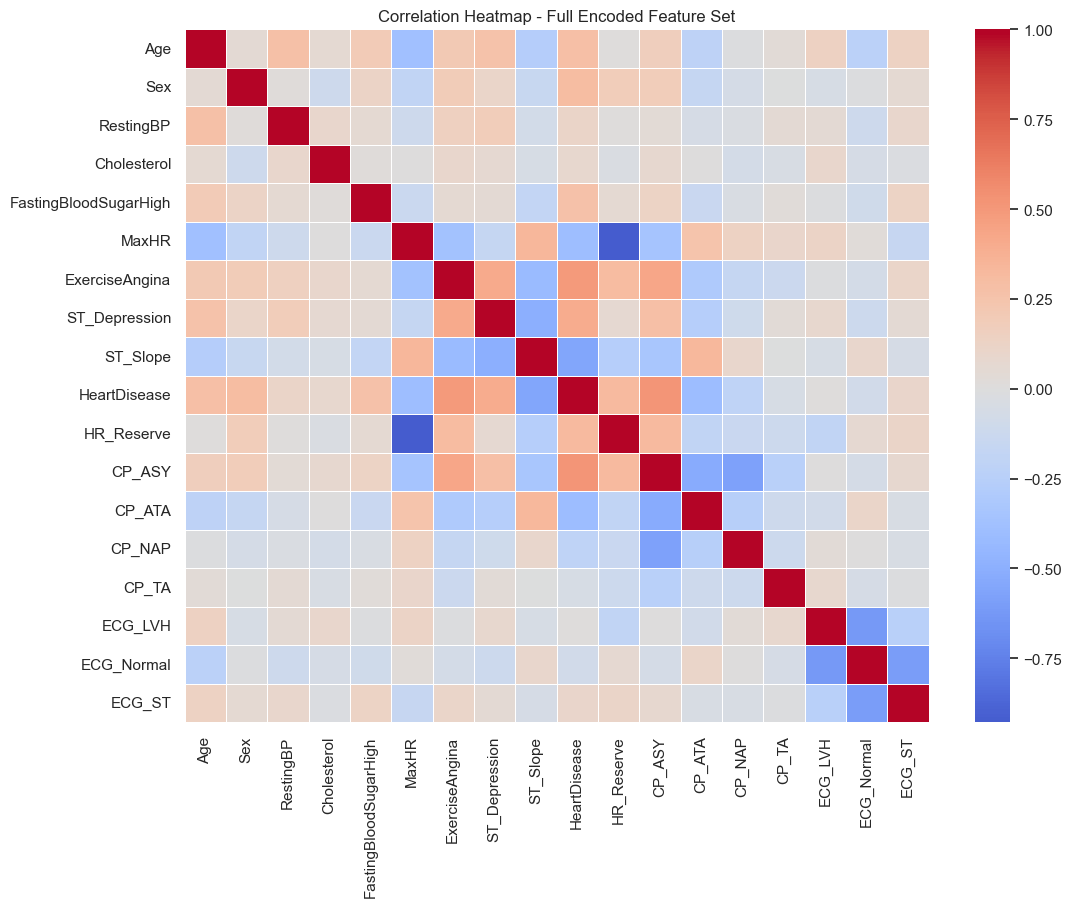

In [30]:
plt.figure(figsize=(12, 9))
corr_ml = df_ml.corr()
sns.heatmap(corr_ml, cmap='coolwarm', center=0, linewidths=0.4, annot=False)
plt.title('Correlation Heatmap - Full Encoded Feature Set')
plt.show()

In [31]:
# Correlation of each feature with the target
target_corr = df_ml.corr()['HeartDisease'].drop('HeartDisease').sort_values(key=abs, ascending=False)
target_corr

ST_Slope                -0.558771
CP_ASY                   0.516716
ExerciseAngina           0.494282
ST_Depression            0.403951
CP_ATA                  -0.401924
MaxHR                   -0.400421
HR_Reserve               0.320196
Sex                      0.305445
Age                      0.282039
FastingBloodSugarHigh    0.267291
CP_NAP                  -0.212964
RestingBP                0.115885
ECG_ST                   0.102527
ECG_Normal              -0.091580
Cholesterol              0.083381
CP_TA                   -0.054790
ECG_LVH                  0.010670
Name: HeartDisease, dtype: float64

In [32]:
# Check for highly correlated PREDICTOR pairs (potential redundancy / multicollinearity)
predictor_corr = df_ml.drop(columns=['HeartDisease']).corr().abs()
upper = predictor_corr.where(np.triu(np.ones(predictor_corr.shape), k=1).astype(bool))
high_corr_pairs = [(col, row, upper.loc[row, col])
                    for col in upper.columns for row in upper.index
                    if pd.notna(upper.loc[row, col]) and upper.loc[row, col] > 0.75]
high_corr_pairs

[('HR_Reserve', 'MaxHR', np.float64(0.9288508799292795))]

**Observation:** `HR_Reserve` and `MaxHR` are highly correlated (|r| ≈ 0.93)  this is expected, since `HR_Reserve` was engineered directly from `MaxHR` and `Age`. Keeping both would introduce multicollinearity, which can destabilise linear models and inflate the apparent importance of this signal. Since `MaxHR` has a stronger direct correlation with the target (-0.40 vs 0.32 for `HR_Reserve`) and is the original, more interpretable measurement, **`HR_Reserve` is dropped** from the final feature set. This is a useful illustration of the feature engineering workflow: an engineered feature can be a reasonable hypothesis, but should still be validated  and discarded  if feature selection reveals it is redundant.

In [33]:
df_ml = df_ml.drop(columns=['HR_Reserve'])
print(f"Shape after removing the redundant HR_Reserve feature: {df_ml.shape}")

Shape after removing the redundant HR_Reserve feature: (918, 17)


In [34]:
# Feature importance via a quick Random Forest (for feature selection guidance only)
X = df_ml.drop(columns=['HeartDisease'])
y = df_ml['HeartDisease']

rf = RandomForestClassifier(n_estimators=300, random_state=42)
rf.fit(X, y)

importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
importances

ST_Slope                 0.219409
CP_ASY                   0.111378
MaxHR                    0.109787
ST_Depression            0.107566
Age                      0.080582
Cholesterol              0.076521
ExerciseAngina           0.074974
RestingBP                0.071950
Sex                      0.036163
CP_ATA                   0.029507
FastingBloodSugarHigh    0.027043
CP_NAP                   0.014582
ECG_LVH                  0.014419
ECG_Normal               0.011267
ECG_ST                   0.008836
CP_TA                    0.006015
dtype: float64

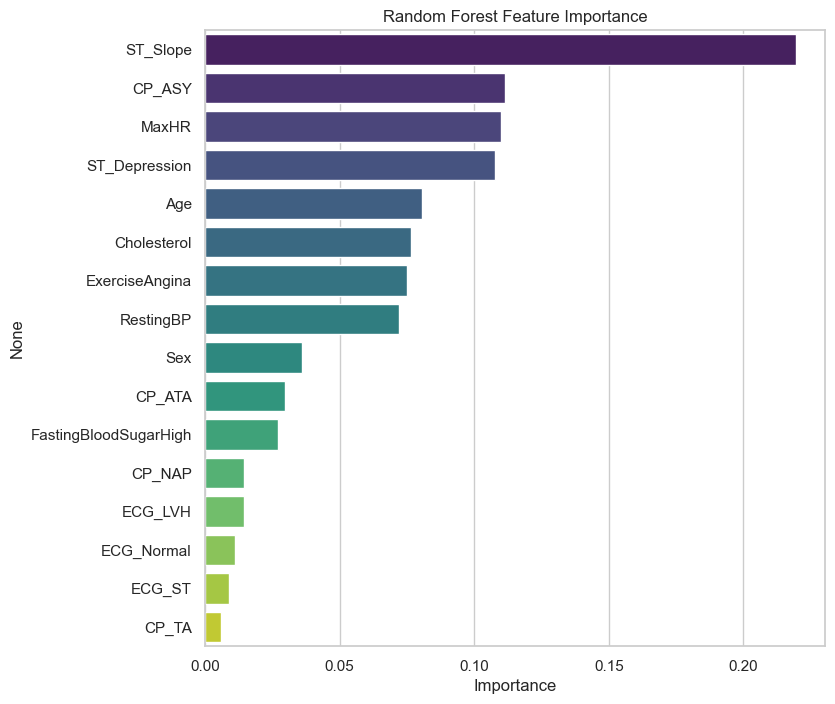

In [35]:
plt.figure(figsize=(8, 8))
sns.barplot(x=importances.values, y=importances.index, hue=importances.index, palette='viridis', legend=False)
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.show()

**Interpretation:** `ST_Slope`, `CP_ASY`, `ST_Depression`, `MaxHR`, and `Cholesterol` emerge as the most influential features for predicting heart disease  consistent with the correlation analysis above and with established cardiology risk factors. This confirms the feature set is both statistically and clinically sound heading into Week 3's modelling stage.

## Part 5 - Final Machine-Learning-Ready Dataset

In [36]:
print(f"Final ML-ready dataset shape: {df_ml.shape}")
df_ml.head()

Final ML-ready dataset shape: (918, 17)


,Age,Sex,RestingBP,Cholesterol,FastingBloodSugarHigh,MaxHR,ExerciseAngina,ST_Depression,ST_Slope,HeartDisease,CP_ASY,CP_ATA,CP_NAP,CP_TA,ECG_LVH,ECG_Normal,ECG_ST
0,-1.076923,1,0.5,0.981132,0,0.944444,0,-0.400000,2,0,0,1,0,0,0,1,0
1,-0.384615,0,1.5,-1.075472,0,0.500000,0,0.266667,1,1,0,0,1,0,0,1,0
2,-1.307692,1,0.0,0.867925,0,-1.111111,0,-0.400000,2,0,0,1,0,0,0,0,1
3,-0.461538,0,0.4,-0.433962,0,-0.833333,1,0.600000,1,1,1,0,0,0,0,1,0
4,0.000000,1,1.0,-0.792453,0,-0.444444,0,-0.400000,2,0,0,0,1,0,0,1,0


In [37]:
df_ml.to_csv('heart_ml_ready.csv', index=False)
print("Saved heart_ml_ready.csv")

Saved heart_ml_ready.csv


**Summary of every preprocessing step applied:**
1. Identified and imputed hidden missing values (`RestingBP` and `Cholesterol` zeros → median imputation).
2. Verified no duplicate records were present.
3. Converted categorical text columns to the `category` dtype.
4. Engineered `HR_Reserve` (age-predicted max heart rate minus observed max heart rate)  later removed at the feature selection stage (step 12) due to multicollinearity with `MaxHR`.
5. Engineered `AgeGroup` for exploratory visualisation (excluded from the final ML dataset to avoid redundancy with `Age`).
6. Renamed `FastingBS` → `FastingBloodSugarHigh` and `Oldpeak` → `ST_Depression` for clarity.
7. Detected outliers via the IQR method and capped extreme `RestingBP`/`Cholesterol` values.
8. Applied Label Encoding to binary variables (`Sex`, `ExerciseAngina`).
9. Applied Ordinal Encoding to `ST_Slope` (preserves natural order).
10. Applied One-Hot Encoding to `ChestPainType` and `RestingECG` (nominal, unordered).
11. Applied RobustScaler to all continuous features, chosen for its resilience to remaining outliers.
12. Identified `HR_Reserve` as redundant with `MaxHR` (r ≈ -0.93) via correlation analysis and removed it from the final feature set, confirmed against Random Forest feature importance.

## Answers to the Business Questions

1. **Which features are most relevant to the prediction problem?** `ST_Slope`, `ST_Depression` (Oldpeak), `ChestPainType` (especially the ASY category), `MaxHR`, and `Cholesterol`  confirmed by both correlation analysis and Random Forest feature importance.
2. **Which variables require encoding?** `Sex` and `ExerciseAngina` (Label Encoding, binary); `ST_Slope` (Ordinal Encoding, natural order); `ChestPainType` and `RestingECG` (One-Hot Encoding, nominal).
3. **Which variables require scaling or normalization?** All continuous numeric features: `Age`, `RestingBP`, `Cholesterol`, `MaxHR`, `ST_Depression`, and the engineered `HR_Reserve`  scaled using `RobustScaler`.
4. **Are there any redundant or highly correlated features?** Yes  the engineered `HR_Reserve` feature turned out to be highly correlated with `MaxHR` (r ≈ -0.93), since it was mathematically derived from it. `HR_Reserve` was removed from the final dataset in favour of `MaxHR`, which has a stronger direct correlation with the target. `AgeGroup` was similarly excluded since it duplicates information already in `Age`. No other predictor pairs showed problematic correlation (|r| < 0.75).
5. **How should missing values and outliers be handled?** Hidden missing values (zeros in `RestingBP`/`Cholesterol`) were imputed with the median; extreme outliers in the same two columns were capped using the IQR method; genuine clinical extremes in `ST_Depression` were retained and handled via robust scaling instead of removal.
6. **What preprocessing techniques improve dataset quality?** Median imputation of hidden missing values, IQR-based outlier capping, appropriate encoding per variable type, and RobustScaler all materially improve the dataset's reliability and suitability for modelling.
7. **Is the dataset ready for machine learning?** Yes  `heart_ml_ready.csv` contains no missing values, no duplicates, fully numeric encoded features, scaled continuous variables, and a verified, non-redundant feature set.